# Full-Corpus Composer Classification

This is my extension to the team notebook (`Final.ipynb`).

The final models were trained on 300 of the 1,637 files (75 per composer) because
loading every piano-roll window as float32 with the 5x augmented copies needs more
than 10 GB of RAM. I wanted to know how much accuracy that cap is costing us, so
this notebook removes it and reruns the exact same setup on the full corpus.

Question: does training on all the data help more than the hyperparameter tuning
we already did?

What I changed vs the team notebook:

- no file cap (but I also rerun the 75-cap with this same code, as the baseline)
- windows stored as uint8/int16 instead of float32, and transposition applied
  randomly inside tf.data instead of pre-computing 5 copies. Same augmentation
  idea, about 25x less memory, which is what makes the full corpus fit.
- added piece-level evaluation (average the window probabilities of each file),
  since that matches how the model would actually be used
- models are always trained fresh in-session, no reloading old checkpoints

Everything else is identical on purpose: same seed, same split ratios, same window
parameters, same architectures, same best configs from the grid search.

To run: upload to Colab, switch the runtime to GPU, run the dataset cell below,
then Run all. Takes about 20-40 min on the free T4. Extracted windows get cached
to build/fc_cache/ so a rerun after a disconnect skips the parsing.


## 1. Setup

In [6]:
# Install the one library Colab does not ship with (fast no-op if present).
%pip install -q pretty_midi
print("setup ok")

setup ok


In [7]:
import os, random, hashlib, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pretty_midi
pretty_midi.pretty_midi.MAX_TICK = 1e7
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# ----------------------------- CONFIG -----------------------------
# Point this at the folder containing Bach/, Beethoven/, Chopin/, Mozart/.
# Colab example after unzipping: "/content/dataset_4composers"
DATASET_PATH = "data"          # Francisco/data if run from the Francisco folder

TARGET_COMPOSERS = ["Bach", "Beethoven", "Chopin", "Mozart"]

# --- identical to the team notebook (Final.ipynb) ---
SEQ_LEN, SEQ_STRIDE = 100, 50          # LSTM: notes per window / hop
PR_FS, PR_TIME, PR_PITCH, PR_STRIDE = 8, 128, 128, 64  # CNN piano roll
TEST_SIZE, VAL_SIZE = 0.15, 0.15
BATCH_SIZE, MAX_EPOCHS, PATIENCE, SEED = 64, 60, 8, 42
MAX_WINDOWS_PER_FILE = 20              # kept to match the team notebook
AUG_SEMITONES = [-2, -1, 1, 2]         # applied randomly on the fly (train only)

# Best grid-search configs from the team notebook — no re-tuning here.
LSTM_CFG = {"lr": 1e-3,  "dropout": 0.3}
CNN_CFG  = {"lr": 5e-4,  "dropout": 0.3}
USE_BATCHNORM = True                   # flip to False for the BatchNorm ablation

# The experiment variable: file cap per composer. None = full corpus.
EXPERIMENT_CAPS = [75, None]

ARTIFACTS_DIR = Path("build/fc_artifacts"); ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path("build/fc_results");        OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = Path("build/fc_cache");        CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ~2x faster conv training on NVIDIA GPUs; harmless elsewhere. The models
# keep their softmax in float32 (see build_cnn/build_lstm) as Keras recommends.
if tf.config.list_physical_devices("GPU"):
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled (float16 compute, float32 softmax).")

def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

set_seeds()
LABEL2IDX = {c: i for i, c in enumerate(TARGET_COMPOSERS)}
IDX2LABEL = {i: c for c, i in LABEL2IDX.items()}
print("Config ready. Caps to compare:", EXPERIMENT_CAPS)

Mixed precision enabled (float16 compute, float32 softmax).
Config ready. Caps to compare: [75, None]


### Getting the dataset on Colab (skip if running locally)

Uncomment ONE option. Option A downloads the public Kaggle dataset directly
(no credentials needed) and keeps only the four target composers.


In [9]:
!curl -sL -o midi-classic-music.zip \
  "https://www.kaggle.com/api/v1/datasets/download/blanderbuss/midi-classic-music"
import zipfile, os
z = zipfile.ZipFile("midi-classic-music.zip")
for info in z.infolist():
    parts = info.filename.split("/")
    if len(parts) >= 3 and parts[0] == "midiclassics" and parts[1] in TARGET_COMPOSERS and not info.is_dir():
        dest = os.path.join("data", parts[1], *parts[2:])
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        with z.open(info) as src, open(dest, "wb") as dst:
            dst.write(src.read())
DATASET_PATH = "data"
print("Dataset ready:", os.listdir("data"))

Dataset ready: ['Mozart', 'Beethoven', 'Chopin', 'Bach']


## 2. Collect, de-duplicate, and validate files

Identical rules to the team notebook: composer inferred from the path
(exactly-one-match), MD5 de-duplication, drop unreadable files and files too
short to yield one window.


In [10]:
def infer_composer(path, targets=TARGET_COMPOSERS):
    matches = [c for c in targets if c.lower() in str(path).lower()]
    return matches[0] if len(matches) == 1 else None

records = []
for ext in ("*.mid", "*.midi", "*.MID", "*.MIDI"):
    for f in Path(DATASET_PATH).rglob(ext):
        comp = infer_composer(f)
        if comp is not None:
            records.append({"path": str(f), "composer": comp})
raw_df = (pd.DataFrame(records).drop_duplicates("path")
          .sort_values("path").reset_index(drop=True))
assert len(raw_df) > 0, "No MIDI files found - check DATASET_PATH"

def md5_of(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

raw_df["md5"] = raw_df["path"].map(md5_of)
dedup_df = raw_df.drop_duplicates("md5").reset_index(drop=True)
print(f"Files: {len(raw_df)}  after de-dup: {len(dedup_df)}")

def probe_midi(path):
    try:
        pm = pretty_midi.PrettyMIDI(path)
        return sum(len(i.notes) for i in pm.instruments)
    except Exception:
        return -1

dedup_df["n_notes"] = dedup_df["path"].map(probe_midi)   # ~3-5 min on full corpus
clean_df = dedup_df[dedup_df["n_notes"] >= SEQ_LEN].reset_index(drop=True)
print(f"Usable files: {len(clean_df)}")
print(clean_df["composer"].value_counts().reindex(TARGET_COMPOSERS))

Files: 1630  after de-dup: 1610
Usable files: 1605
composer
Bach         1012
Beethoven     207
Chopin        132
Mozart        254
Name: count, dtype: int64


## 3. Feature extraction

The team notebook ran out of RAM because it stored float32 windows with the 4
transposed copies pre-computed. Here I store base windows only, as uint8 (binary
piano rolls) and int16 (pitch tokens). The full corpus fits in well under 1 GB.

Windows also carry a file_id so predictions can be aggregated back to piece
level at evaluation time.


In [11]:
def extract_both(path):
    """Parse the MIDI file ONCE and derive both representations from it.
    (Parsing dominates extraction time; the team notebook parsed twice.)"""
    try:
        pm = pretty_midi.PrettyMIDI(path)
    except Exception:
        return None, None
    notes = [(n.start, n.pitch) for inst in pm.instruments
             if not inst.is_drum for n in inst.notes]
    seq = None
    if len(notes) >= SEQ_LEN:
        notes.sort(key=lambda x: x[0])
        seq = np.array([p for _, p in notes], dtype=np.int16)
    roll = None
    if len(pm.instruments) > 0:
        r = pm.get_piano_roll(fs=PR_FS)
        if r.shape[1] >= PR_TIME:
            roll = (r > 0).astype(np.uint8)
    return seq, roll

def windows_1d(seq, size, stride, cap=MAX_WINDOWS_PER_FILE):
    out = []
    for start in range(0, len(seq) - size + 1, stride):
        out.append(seq[start:start + size])
        if cap is not None and len(out) >= cap:
            break
    return out

def windows_2d(roll, size, stride, cap=MAX_WINDOWS_PER_FILE):
    out = []
    for start in range(0, roll.shape[1] - size + 1, stride):
        out.append(roll[:, start:start + size])
        if cap is not None and len(out) >= cap:
            break
    return out

def build_arrays(files, labels):
    """Return dict with LSTM + CNN base windows, labels, and file ids."""
    seq_X, seq_y, seq_f = [], [], []
    cnn_X, cnn_y, cnn_f = [], [], []
    for fid, (path, lab) in enumerate(zip(files, labels)):
        seq, roll = extract_both(path)
        if seq is not None:
            for w in windows_1d(seq, SEQ_LEN, SEQ_STRIDE):
                seq_X.append(w); seq_y.append(lab); seq_f.append(fid)
        if roll is not None:
            for w in windows_2d(roll, PR_TIME, PR_STRIDE):
                cnn_X.append(w); cnn_y.append(lab); cnn_f.append(fid)
    return {
        "seq": (np.array(seq_X, np.int16), np.array(seq_y, np.int32), np.array(seq_f)),
        "cnn": (np.array(cnn_X, np.uint8)[..., None], np.array(cnn_y, np.int32), np.array(cnn_f)),
    }

def cached_build_arrays(tag, split, files, labels):
    """Extraction is deterministic given (cap, split), so cache it to disk.
    Delete build/fc_cache/ if you change any window/extraction parameter."""
    p = CACHE_DIR / f"{tag}_{split}.npz"
    if p.exists():
        z = np.load(p)
        print(f"  [{tag}/{split}] loaded from cache")
        return {"seq": (z["sX"], z["sy"], z["sf"]),
                "cnn": (z["cX"], z["cy"], z["cf"])}
    out = build_arrays(files, labels)
    (sX, sy, sf), (cX, cy, cf) = out["seq"], out["cnn"]
    np.savez_compressed(p, sX=sX, sy=sy, sf=sf, cX=cX, cy=cy, cf=cf)
    print(f"  [{tag}/{split}] extracted and cached -> {p}")
    return out

print("Extraction helpers defined.")

Extraction helpers defined.


## 4. tf.data pipelines

Training windows get a random semitone shift from {-2,-1,0,+1,+2} each epoch.
The team notebook baked in all four shifts as extra copies; sampling them
randomly covers the same space without the 5x memory. Validation and test are
never augmented.


In [12]:
SHIFTS = tf.constant([0] + AUG_SEMITONES, dtype=tf.int32)

def _aug_seq(x, y):
    s = SHIFTS[tf.random.uniform([], 0, len(AUG_SEMITONES) + 1, tf.int32)]
    x = tf.clip_by_value(tf.cast(x, tf.int32) + s, 0, 127)
    return x, y

def _shift_roll(x, s):
    # x: (128, T, 1). Row index = pitch, so shifting rows transposes.
    def up():   return tf.pad(x, [[s, 0], [0, 0], [0, 0]])[:PR_PITCH]
    def down(): return tf.pad(x, [[0, -s], [0, 0], [0, 0]])[-PR_PITCH:]
    return tf.cond(s > 0, up, down)

def _aug_roll(x, y):
    s = SHIFTS[tf.random.uniform([], 0, len(AUG_SEMITONES) + 1, tf.int32)]
    x = tf.cond(tf.equal(s, 0), lambda: x, lambda: _shift_roll(x, s))
    return x, y

def make_ds(X, y, kind, training):
    if kind == "seq":
        ds = tf.data.Dataset.from_tensor_slices((X.astype(np.int32), y))
        aug = _aug_seq
    else:
        ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y))
        aug = _aug_roll
    if training:
        ds = ds.shuffle(min(len(y), 20000), seed=SEED).map(
            aug, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Pipelines defined.")

Pipelines defined.


## 5. Models — identical architectures to the team notebook

`USE_BATCHNORM=False` reproduces the ablation the team flagged as future work
(BatchNorm on sparse binary input is suspected of destabilizing validation).


In [13]:
def build_lstm(lr, dropout):
    set_seeds()
    m = models.Sequential([
        layers.Input(shape=(SEQ_LEN,)),
        layers.Embedding(input_dim=129, output_dim=64),
        layers.LSTM(128, return_sequences=True, dropout=dropout),
        layers.LSTM(64, dropout=dropout),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(len(TARGET_COMPOSERS), activation="softmax", dtype="float32"),
    ], name="LSTM_full_corpus")
    m.compile(optimizer=optimizers.Adam(lr),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def build_cnn(lr, dropout):
    set_seeds()
    L = [layers.Input(shape=(PR_PITCH, PR_TIME, 1))]
    for f in (32, 64, 128):
        L.append(layers.Conv2D(f, 3, padding="same", activation="relu"))
        if USE_BATCHNORM:
            L.append(layers.BatchNormalization())
        L.append(layers.MaxPooling2D(2))
    L += [layers.GlobalAveragePooling2D(),
          layers.Dense(128, activation="relu"),
          layers.Dropout(dropout),
          layers.Dense(len(TARGET_COMPOSERS), activation="softmax", dtype="float32")]
    m = models.Sequential(L, name="CNN_full_corpus")
    m.compile(optimizer=optimizers.Adam(lr),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

print("Model builders defined.")

Model builders defined.


## 6. Training and evaluation

Same callbacks as the team notebook (early stopping on val loss with best-weights
restore, checkpoint, LR reduction). Checkpoints are tagged with the cap so a
75-cap model can't get mixed up with a full-corpus one, and nothing is loaded
from disk: every number below comes from a model trained in this session (we got
burned by stale checkpoints in the main notebook review).

`evaluate_two_level` reports metrics per window and per piece. Piece-level =
average the window probability vectors of each file, then take the argmax.


In [14]:
def train(build_fn, cfg, tr_ds, va_ds, class_weight, tag):
    model = build_fn(**cfg)
    cbs = [
        callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                restore_best_weights=True),
        callbacks.ModelCheckpoint(str(ARTIFACTS_DIR / f"{tag}.keras"),
                                  monitor="val_loss", save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-5),
    ]
    hist = model.fit(tr_ds, validation_data=va_ds, epochs=MAX_EPOCHS,
                     class_weight=class_weight, callbacks=cbs, verbose=2)
    return model, hist

def evaluate_two_level(model, X, y, file_ids, kind, title):
    ds = make_ds(X, y, kind, training=False)
    proba = model.predict(ds, verbose=0)

    # ---- window level ----
    yw = proba.argmax(1)
    acc_w = accuracy_score(y, yw)
    pw, rw, fw, _ = precision_recall_fscore_support(y, yw, average="macro", zero_division=0)

    # ---- piece level: average window probabilities per file ----
    pieces = pd.DataFrame(proba)
    pieces["fid"] = file_ids
    pieces["true"] = y
    agg = pieces.groupby("fid").agg({**{i: "mean" for i in range(len(TARGET_COMPOSERS))},
                                     "true": "first"})
    yp_true = agg["true"].values
    yp_pred = agg[list(range(len(TARGET_COMPOSERS)))].values.argmax(1)
    acc_p = accuracy_score(yp_true, yp_pred)
    pp, rp, fp_, _ = precision_recall_fscore_support(yp_true, yp_pred,
                                                     average="macro", zero_division=0)

    print(f"===== {title} =====")
    print(f"window: acc={acc_w:.4f}  macro P/R/F1 = {pw:.3f}/{rw:.3f}/{fw:.3f}  (n={len(y)})")
    print(f"piece : acc={acc_p:.4f}  macro P/R/F1 = {pp:.3f}/{rp:.3f}/{fp_:.3f}  (n={len(yp_true)})")
    print(classification_report(yp_true, yp_pred, target_names=TARGET_COMPOSERS,
                                zero_division=0))
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    sns.heatmap(confusion_matrix(yp_true, yp_pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=TARGET_COMPOSERS, yticklabels=TARGET_COMPOSERS, ax=ax)
    ax.set_title(f"{title} - piece-level confusion"); ax.set_xlabel("predicted"); ax.set_ylabel("true")
    plt.tight_layout(); plt.show()

    return {"acc_window": acc_w, "f1_macro_window": fw,
            "acc_piece": acc_p, "f1_macro_piece": fp_,
            "precision_macro_piece": pp, "recall_macro_piece": rp}

print("Train/eval utilities defined.")

Train/eval utilities defined.


## 7. Run both experiments (cap = 75, then full corpus)


EXPERIMENT: cap75
files -> train 210  val 45  test 45
  [cap75/train] extracted and cached -> build/fc_cache/cap75_train.npz
  [cap75/val] extracted and cached -> build/fc_cache/cap75_val.npz
  [cap75/test] extracted and cached -> build/fc_cache/cap75_test.npz

--- LSTM [cap75] --- train windows: 3422 (1 MB)
Epoch 1/60
54/54 - 9s - 166ms/step - accuracy: 0.2566 - loss: 1.3840 - val_accuracy: 0.2913 - val_loss: 1.3695 - learning_rate: 0.0010
Epoch 2/60
54/54 - 1s - 18ms/step - accuracy: 0.3124 - loss: 1.3481 - val_accuracy: 0.2829 - val_loss: 1.4007 - learning_rate: 0.0010
Epoch 3/60
54/54 - 1s - 20ms/step - accuracy: 0.3179 - loss: 1.3284 - val_accuracy: 0.3249 - val_loss: 1.3540 - learning_rate: 0.0010
Epoch 4/60
54/54 - 1s - 17ms/step - accuracy: 0.3343 - loss: 1.3174 - val_accuracy: 0.2591 - val_loss: 1.4285 - learning_rate: 0.0010
Epoch 5/60
54/54 - 1s - 17ms/step - accuracy: 0.3524 - loss: 1.3034 - val_accuracy: 0.2829 - val_loss: 1.4179 - learning_rate: 0.0010
Epoch 6/60
54/54 -

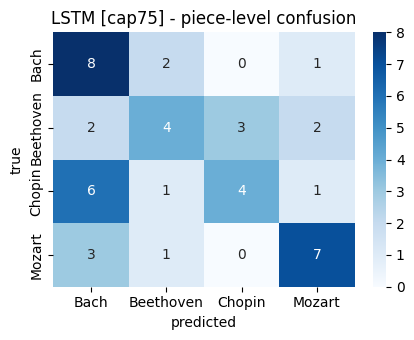


--- CNN [cap75] --- train windows: 3207 (53 MB)
Epoch 1/60
51/51 - 29s - 573ms/step - accuracy: 0.4060 - loss: 1.2596 - val_accuracy: 0.3254 - val_loss: 1.4016 - learning_rate: 5.0000e-04
Epoch 2/60
51/51 - 1s - 21ms/step - accuracy: 0.5557 - loss: 1.0176 - val_accuracy: 0.1486 - val_loss: 1.4995 - learning_rate: 5.0000e-04
Epoch 3/60
51/51 - 1s - 21ms/step - accuracy: 0.6227 - loss: 0.8818 - val_accuracy: 0.1530 - val_loss: 1.8531 - learning_rate: 5.0000e-04
Epoch 4/60
51/51 - 1s - 21ms/step - accuracy: 0.6539 - loss: 0.7983 - val_accuracy: 0.1486 - val_loss: 2.6621 - learning_rate: 5.0000e-04
Epoch 5/60
51/51 - 1s - 21ms/step - accuracy: 0.7019 - loss: 0.7064 - val_accuracy: 0.1530 - val_loss: 3.4369 - learning_rate: 2.5000e-04
Epoch 6/60
51/51 - 1s - 21ms/step - accuracy: 0.7172 - loss: 0.6696 - val_accuracy: 0.1530 - val_loss: 4.7729 - learning_rate: 2.5000e-04
Epoch 7/60
51/51 - 1s - 21ms/step - accuracy: 0.7365 - loss: 0.6286 - val_accuracy: 0.1783 - val_loss: 5.1222 - learning_

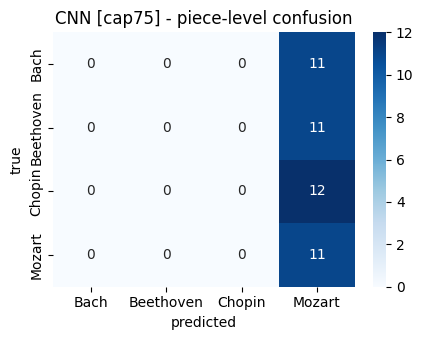


EXPERIMENT: full
files -> train 1123  val 241  test 241
  [full/train] extracted and cached -> build/fc_cache/full_train.npz
  [full/val] extracted and cached -> build/fc_cache/full_val.npz
  [full/test] extracted and cached -> build/fc_cache/full_test.npz

--- LSTM [full] --- train windows: 15833 (3 MB)
Epoch 1/60
248/248 - 8s - 32ms/step - accuracy: 0.4681 - loss: 1.3381 - val_accuracy: 0.5730 - val_loss: 1.2488 - learning_rate: 0.0010
Epoch 2/60
248/248 - 5s - 21ms/step - accuracy: 0.5106 - loss: 1.3031 - val_accuracy: 0.4442 - val_loss: 1.3177 - learning_rate: 0.0010
Epoch 3/60
248/248 - 5s - 19ms/step - accuracy: 0.5113 - loss: 1.2880 - val_accuracy: 0.5350 - val_loss: 1.2428 - learning_rate: 0.0010
Epoch 4/60
248/248 - 6s - 22ms/step - accuracy: 0.5247 - loss: 1.2701 - val_accuracy: 0.5706 - val_loss: 1.1713 - learning_rate: 0.0010
Epoch 5/60
248/248 - 5s - 18ms/step - accuracy: 0.5135 - loss: 1.2526 - val_accuracy: 0.5543 - val_loss: 1.1347 - learning_rate: 0.0010
Epoch 6/60
24

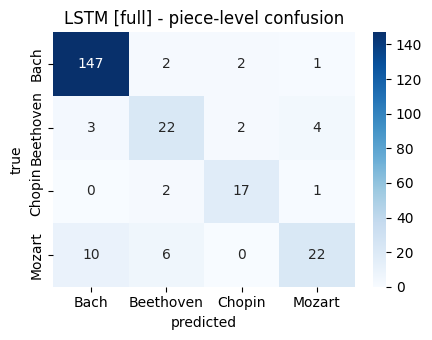


--- CNN [full] --- train windows: 14616 (239 MB)
Epoch 1/60
229/229 - 23s - 102ms/step - accuracy: 0.5827 - loss: 1.0554 - val_accuracy: 0.3924 - val_loss: 1.3529 - learning_rate: 5.0000e-04
Epoch 2/60
229/229 - 5s - 21ms/step - accuracy: 0.6977 - loss: 0.8157 - val_accuracy: 0.1624 - val_loss: 4.1329 - learning_rate: 5.0000e-04
Epoch 3/60
229/229 - 5s - 20ms/step - accuracy: 0.7333 - loss: 0.7185 - val_accuracy: 0.4883 - val_loss: 1.5807 - learning_rate: 5.0000e-04
Epoch 4/60
229/229 - 5s - 21ms/step - accuracy: 0.7622 - loss: 0.6405 - val_accuracy: 0.3687 - val_loss: 1.8342 - learning_rate: 5.0000e-04
Epoch 5/60
229/229 - 5s - 20ms/step - accuracy: 0.7967 - loss: 0.5607 - val_accuracy: 0.4962 - val_loss: 1.4483 - learning_rate: 2.5000e-04
Epoch 6/60
229/229 - 5s - 21ms/step - accuracy: 0.8095 - loss: 0.5310 - val_accuracy: 0.5812 - val_loss: 1.0815 - learning_rate: 2.5000e-04
Epoch 7/60
229/229 - 5s - 21ms/step - accuracy: 0.8186 - loss: 0.4931 - val_accuracy: 0.6279 - val_loss: 1.0

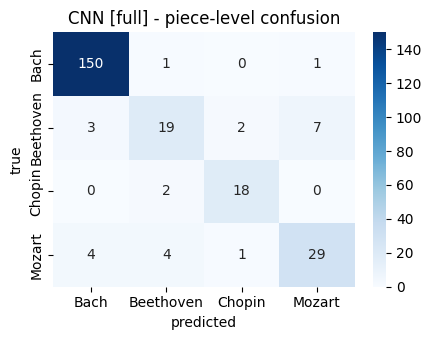

In [15]:
def run_experiment(cap):
    tag = f"cap{cap}" if cap else "full"
    print(f"\n{'='*60}\nEXPERIMENT: {tag}\n{'='*60}")
    set_seeds()

    files = clean_df["path"].values
    labels = clean_df["composer"].map(LABEL2IDX).values
    if cap is not None:
        keep = []
        rng = np.random.RandomState(SEED)
        for c in range(len(TARGET_COMPOSERS)):
            idx = np.where(labels == c)[0]
            rng.shuffle(idx)
            keep.extend(idx[:cap])
        keep = np.array(sorted(keep))
        files, labels = files[keep], labels[keep]

    f_tv, f_te, y_tv, y_te = train_test_split(files, labels, test_size=TEST_SIZE,
                                              stratify=labels, random_state=SEED)
    f_tr, f_va, y_tr, y_va = train_test_split(f_tv, y_tv,
                                              test_size=VAL_SIZE / (1 - TEST_SIZE),
                                              stratify=y_tv, random_state=SEED)
    assert not (set(f_tr) & set(f_te)) and not (set(f_tr) & set(f_va)) \
           and not (set(f_va) & set(f_te)), "split leakage!"
    print(f"files -> train {len(f_tr)}  val {len(f_va)}  test {len(f_te)}")

    tr = cached_build_arrays(tag, "train", f_tr, y_tr)
    va = cached_build_arrays(tag, "val",   f_va, y_va)
    te = cached_build_arrays(tag, "test",  f_te, y_te)

    rows = {}
    for kind, build_fn, cfg, name in [("seq", build_lstm, LSTM_CFG, "LSTM"),
                                      ("cnn", build_cnn, CNN_CFG, "CNN")]:
        Xtr, ytr, _ = tr[kind]
        Xva, yva, _ = va[kind]
        Xte, yte, fte = te[kind]
        mb = Xtr.nbytes / 1e6
        print(f"\n--- {name} [{tag}] --- train windows: {len(ytr)} ({mb:.0f} MB)")
        cw = compute_class_weight("balanced", classes=np.arange(len(TARGET_COMPOSERS)), y=ytr)
        cw = {int(i): float(w) for i, w in enumerate(cw)}
        model, hist = train(build_fn, cfg,
                            make_ds(Xtr, ytr, kind, True),
                            make_ds(Xva, yva, kind, False),
                            cw, tag=f"{name.lower()}_{tag}")
        metrics = evaluate_two_level(model, Xte, yte, fte, kind, f"{name} [{tag}]")
        rows[name] = {"experiment": tag, "model": name,
                      "train_files": len(f_tr), "train_windows": len(ytr), **metrics}
    return rows

all_rows = []
for cap in EXPERIMENT_CAPS:
    res = run_experiment(cap)
    all_rows += list(res.values())

## 8. Comparison table


                  train_files  train_windows  acc_window  f1_macro_window  \
experiment model                                                            
cap75      LSTM           210           3422      0.3811           0.3808   
           CNN            210           3207      0.2815           0.1098   
full       LSTM          1123          15833      0.7086           0.6399   
           CNN           1123          14616      0.7509           0.6836   

                  acc_piece  f1_macro_piece  precision_macro_piece  \
experiment model                                                     
cap75      LSTM      0.5111          0.5030                 0.5322   
           CNN       0.2444          0.0982                 0.0611   
full       LSTM      0.8631          0.7842                 0.8004   
           CNN       0.8963          0.8222                 0.8318   

                  recall_macro_piece  
experiment model                      
cap75      LSTM               0.5152  

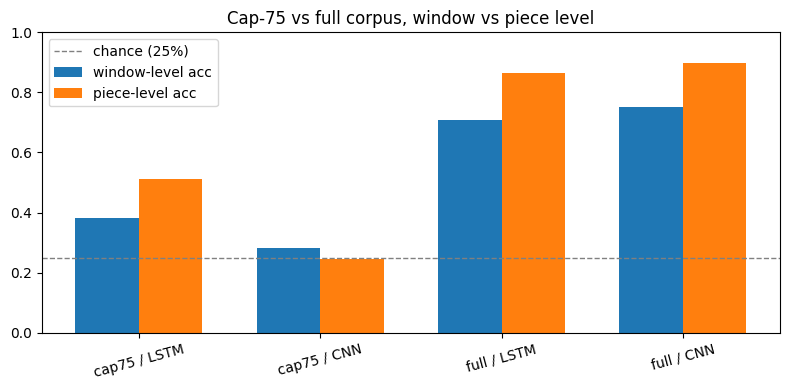

Saved: build/fc_results/full_corpus_comparison.csv


In [16]:
comparison = pd.DataFrame(all_rows).set_index(["experiment", "model"]).round(4)
print(comparison)
comparison.to_csv(OUT_DIR / "full_corpus_comparison.csv")

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = comparison.reset_index()
plot_df["label"] = plot_df["experiment"] + " / " + plot_df["model"]
x = np.arange(len(plot_df)); w = 0.35
ax.bar(x - w/2, plot_df["acc_window"], w, label="window-level acc")
ax.bar(x + w/2, plot_df["acc_piece"],  w, label="piece-level acc")
ax.set_xticks(x); ax.set_xticklabels(plot_df["label"], rotation=15)
ax.axhline(0.25, ls="--", c="gray", lw=1, label="chance (25%)")
ax.set_ylim(0, 1); ax.legend(); ax.set_title("Cap-75 vs full corpus, window vs piece level")
plt.tight_layout(); plt.savefig(OUT_DIR / "full_corpus_comparison.png", dpi=150); plt.show()
print("Saved:", OUT_DIR / "full_corpus_comparison.csv")

## 9. Conclusions

Fill in from the section 8 table after running:

- full corpus vs cap-75: CNN piece accuracy went from __ to __, LSTM from __ to __
- piece-level vs window-level added roughly __ points
- check the confusion matrices: did Bach stop being the weak class once all his
  files were included?

For the paper this goes in Model Optimization as the data-scaling experiment.
The EDA (Francisco/eda/) explains why window share, not file count, drives the
imbalance.

Possible follow-up: set USE_BATCHNORM = False and rerun for the BatchNorm
ablation we discussed.
